In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def initial_regions(image, block_size=20):
    h, w, _ = image.shape
    regions = []

    for y in range(0, h, block_size):
        for x in range(0, w, block_size):

            bw = min(block_size, w - x)
            bh = min(block_size, h - y)

            region = {
                "x": x,
                "y": y,
                "w": bw,
                "h": bh,
                "pixels": image[y:y + bh, x:x + bw]
            }

            regions.append(region)

    return regions




In [4]:
def region_similarity(r1, r2):

    mean1 = np.mean(r1["pixels"], axis=(0, 1))
    mean2 = np.mean(r2["pixels"], axis=(0, 1))

    return np.linalg.norm(mean1 - mean2)




In [5]:
def merge_regions(r1, r2, image):

    x1 = min(r1["x"], r2["x"])
    y1 = min(r1["y"], r2["y"])

    x2 = max(r1["x"] + r1["w"], r2["x"] + r2["w"])
    y2 = max(r1["y"] + r1["h"], r2["y"] + r2["h"])

    merged_pixels = image[y1:y2, x1:x2]

    return {
        "x": x1,
        "y": y1,
        "w": x2 - x1,
        "h": y2 - y1,
        "pixels": merged_pixels
    }




In [6]:
def selective_search_from_scratch(image, threshold=25):

    regions = initial_regions(image)

    merged_regions = []

    while regions:

        r = regions.pop(0)

        merged_flag = False

        for i, other in enumerate(regions):

            sim = region_similarity(r, other)

            if sim < threshold:

                new_region = merge_regions(r, other, image)

                regions.pop(i)

                regions.append(new_region)

                merged_flag = True
                break

        if not merged_flag:
            merged_regions.append(r)

    return merged_regions




In [7]:
def draw_regions(image, regions):

    output = image.copy()

    for r in regions:

        cv2.rectangle(
            output,
            (r["x"], r["y"]),
            (r["x"] + r["w"], r["y"] + r["h"]),
            (0, 255, 0),
            1
        )

    return output




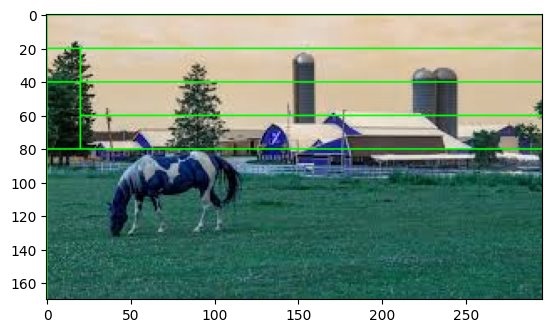

In [8]:
image = cv2.imread("farm.jpg")

regions = selective_search_from_scratch(image, threshold=30)

result = draw_regions(image, regions)

plt.imshow(result)